In [2]:
import os
import numpy as np
import torch
import pickle

from sensorium.utility import get_data, set_random_seed
from sensorium.utility.scores import get_correlations

from utils import load_model_from_config, get_knn_curve, get_ari_curve, whiten, get_cka, get_rsa, get_metrics
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    # 'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

for file in [
    "static20457-5-9-94c6ff995dac583098847cfecd43e7b6",
    # "static20622-2-14-94c6ff995dac583098847cfecd43e7b6",
    # "static20892-10-10-94c6ff995dac583098847cfecd43e7b6",
    "static22223-2-15-94c6ff995dac583098847cfecd43e7b6",
    "static22564-2-12-94c6ff995dac583098847cfecd43e7b6",
    "static22620-4-15-94c6ff995dac583098847cfecd43e7b6",
    "static23555-5-12-94c6ff995dac583098847cfecd43e7b6",
]:
    filenames.append(os.path.join("/user/turishcheva/more_data_like_sensorium_2022", file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
for file in filenames:
    area_path = os.path.join(file, 'meta/neurons/area.npy')
    layer_path = os.path.join(file, 'meta/neurons/layer.npy')
    area = np.load(area_path)
    layer = np.load(layer_path)
    print(np.unique(area), np.unique(layer))
# area = np.load('/srv/user/turishcheva/more_data_like_sensorium_2022/static22223-2-15-94c6ff995dac583098847cfecd43e7b6/meta/neurons/area.npy')

['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']
['V1'] ['L2/3']


In [4]:
paths = [
    '../training/runs/sigma/4/sigma4_seed0',
    '../training/runs/sigma/4/sigma4_seed42',
    '../training/runs/sigma/4/sigma4_seed123',
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]

paths = [
    f'../training/runs/final/final_11mice_seed{seed}' 
    for seed in [17, 21, 27, 33, 39, 48, 50, 56, 72, 77, 78, 83, 84, 91, 94, 95]
]

models = [
    load_model_from_config(path, dataloaders, device)
    for path in paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [5]:
num_batches = 50

In [ ]:
readouts = [
    {k: model.readout[k].features.squeeze().detach().cpu() for k in data_keys}
    for model in models
]

cache_file = 'data/readouts_11mice.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        white_readouts = pickle.load(f)
else:
    white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100, as_dict=True) 
        for model in models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(white_readouts, f)

In [6]:
normed_readouts = [
    {k: v / v.norm(dim=1, keepdim=True) for k, v in r.items()}
    for r in white_readouts
]

## deduplicate

In [7]:
n_batches = 50
corr_threshold = 0.8
dist_threshold = 4
corrs = []
duplicates = {}

for key in data_keys:
    responses = []
    loader = dataloaders['train'][key]
    for i, batch in enumerate(loader):
        response = batch[1]
        responses.append(batch[1].cpu())

        if i == n_batches - 1:
            print('breaking')
            break
    responses = torch.cat(responses).T
    corr = torch.corrcoef(responses)
    corrs.append(corr)
    grid = torch.from_numpy(loader.dataset.neurons.cell_motor_coordinates[:, :2]).to(torch.float32)
    dist = torch.cdist(grid, grid)

    corr_mask = (corr > corr_threshold).tril(diagonal=-1)
    dist_mask = (dist < dist_threshold).tril(diagonal=-1)

    duplicate = (corr_mask & dist_mask).any(dim=1)
    duplicates[key] = duplicate
    print(duplicate.sum().item() / duplicate.shape[0])

0.514998636487592
0.5146949864163991
0.5265819662020476
0.5379837553750597
0.5185185185185185
0.5329520697167756
0.5724330061024144


In [8]:
for k, loader in dataloaders['train'].items():
    grid = loader.dataset.neurons.cell_motor_coordinates
    n_layers = len(np.unique(grid[:, 2]))
    print(k, '\t', grid[:, 2].max() - grid[:, 2].min(), n_layers, grid.shape)

23343-5-17 	 45 10 (7334, 3)
23964-4-22 	 45 10 (8098, 3)
23656-14-22 	 45 10 (8107, 3)
21067-10-18 	 45 10 (8372, 3)
26872-17-20 	 45 10 (7776, 3)
22846-10-16 	 45 10 (7344, 3)
27204-5-13 	 45 10 (7538, 3)


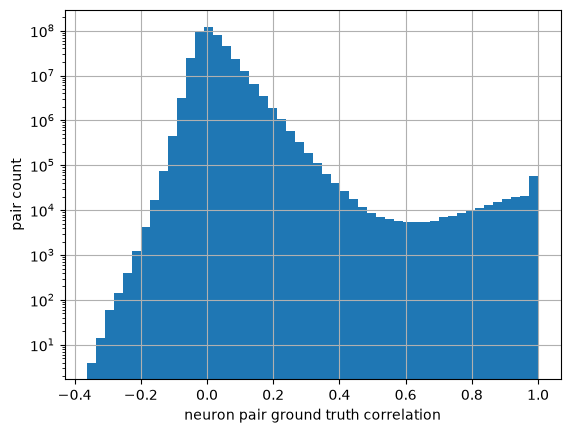

In [9]:
plt.hist(torch.cat([c.flatten(0, 1) for c in corrs]), bins=50)
plt.yscale('log')
plt.grid()
plt.xlabel('neuron pair ground truth correlation')
plt.ylabel('pair count')
plt.show()

In [10]:
filtered_readouts = [
    {k: r[k][~duplicates[k]] for k in data_keys}
    for r in normed_readouts
]

combined_readouts = [
    torch.cat(list(r.values()))
    for r in filtered_readouts
]

In [13]:
offset = 0
offsets = [offset]
for key in data_keys:
    n_neurons = filtered_readouts[0][key].shape[0]
    offset += n_neurons
    offsets.append(offset)

In [20]:
n_clusters_range = list(range(2, 31))

In [21]:
cache_file = 'data/curve6.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        curve = pickle.load(f)
else:
    seeds = [0, 1, 2, 3, 4]#, 5, 6, 7, 8, 9]
    curve, _ = get_ari_curve(combined_readouts, n_clusters_range, seeds)

    with open(cache_file, 'wb') as f:
        pickle.dump(curve, f)

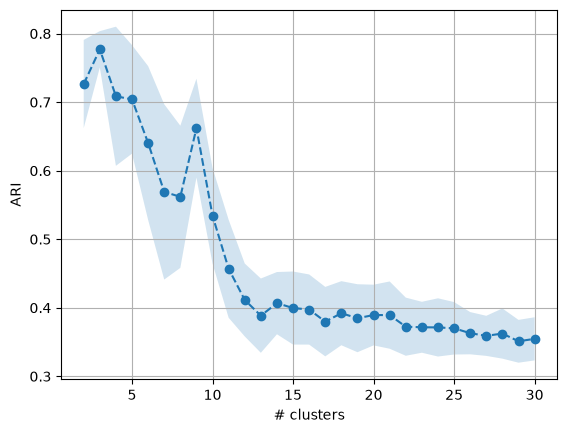

In [22]:
m, s = np.array(curve)
plt.plot(n_clusters_range, m, marker='o', linestyle='--')
plt.fill_between(n_clusters_range, m - s, m + s, alpha=0.2)
# plt.xticks(n_clusters_range)
plt.ylabel('ARI')
plt.xlabel('# clusters')
plt.grid()
plt.show()

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

n_clusters = 3
seed = 0

labels = []
for points in combined_readouts:
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
    label = kmeans.fit_predict(points)
    labels.append(label)

In [24]:
means = []
stds = []

for mouse in range(7):
    s, e = offsets[mouse:(mouse+2)]
    aris = []
    for i in range(len(labels)):
        for j in range(i):
            labels_i = labels[i][s:e]
            labels_j = labels[j][s:e]
            aris.append(adjusted_rand_score(labels_i, labels_j))
    aris = np.array(aris)
    means.append(aris.mean())
    stds.append(aris.std(ddof=1))

In [6]:
scores = []
for model in models:
    score = get_correlations(model, dataloaders['validation'], device=device, as_dict=True)
    score = {k: v.mean() for k, v in score.items()}
    scores.append(score)

In [7]:
scores = [
    np.array([s[k] for s in scores]).mean()
    for k in data_keys
]

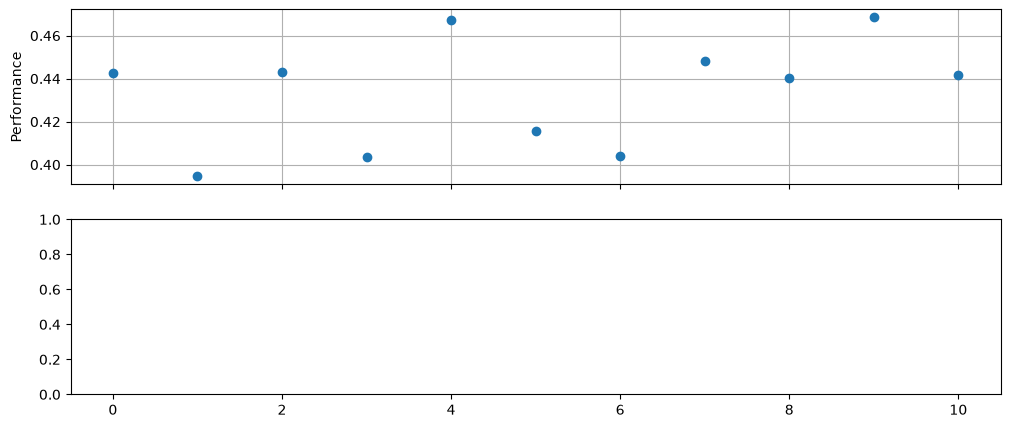

In [10]:
fig, axs = plt.subplots(2, figsize=(12, 5), sharex=True)

ax = axs[0]
ax.plot(list(range(11)), scores, linestyle='', marker='o')
ax.set_ylabel('Performance')
ax.grid()

# ax = axs[1]
# ax.errorbar(list(range(7)), means, yerr=stds, marker='o', linestyle='')
# ax.set_xlabel('Mouse')
# ax.set_ylabel('ARI')
# ax.grid()

plt.show()

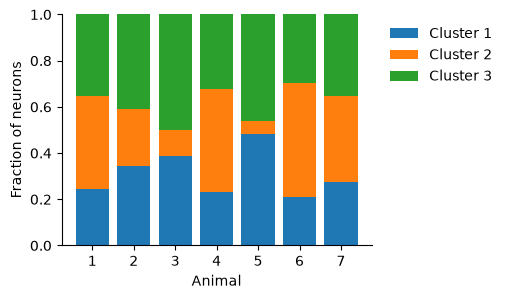

In [26]:
n_mice = len(normed_readouts[0])
all_counts = []
for mouse in range(n_mice):
    s, e = offsets[mouse:(mouse + 2)]
    unique, counts = np.unique(labels[3][s:e], return_counts=True)
    all_counts.append(counts)

all_counts = np.array(all_counts)
props = all_counts / all_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(4, 3))
x = np.arange(n_mice)
bottom = np.zeros(n_mice)
colors = [f'C{i}' for i in range(n_clusters)]

for k in range(n_clusters):
    ax.bar(x, props[:, k], bottom=bottom, color=colors[k], label=f'Cluster {k + 1}')
    bottom += props[:, k]

ax.set_xticks(x)
ax.set_xticklabels([f'{i + 1}' for i in range(n_mice)])
ax.set_xlabel('Animal')
ax.set_ylabel('Fraction of neurons')
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

## animal

In [27]:
animals = []
for i, key in enumerate(data_keys):
    n_neurons = filtered_readouts[0][key].shape[0]
    animals.append(i * torch.ones(n_neurons))
animals = torch.cat(animals)

In [28]:
aris = []
for label in labels:
    aris.append(
        adjusted_rand_score(label, animals)
    )
aris = np.array(aris)
print('mean', aris.mean())
print('std', aris.std(ddof=1))

mean 0.02620579933293697
std 0.0025199771245579313


## depth

In [29]:
layers = []
for i, key in enumerate(data_keys):
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates
    depths = torch.from_numpy(grid[~duplicates[key], 2])
    unique, layer = torch.unique(depths, return_inverse=True)
    layers.append(layer)
layers = torch.cat(layers)

In [30]:
aris = []
for label in labels:
    aris.append(
        adjusted_rand_score(label, layers)
    )
aris = np.array(aris)
print('mean', aris.mean())
print('std', aris.std(ddof=1))

mean 0.0014610167316314732
std 0.0001688596486616352


In [31]:
grids = []
grid_labels = []

offset = 0
offsets = [offset]
for key in data_keys:
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates
    grid = torch.from_numpy(grid[~duplicates[key], :2])
    grids.append(grid)

    n_neurons = grid.shape[0]
    grid_labels.append(labels[3][offset:(offset + n_neurons)])
    offset += n_neurons
    offsets.append(offset)
# grids = torch.cat(grids)

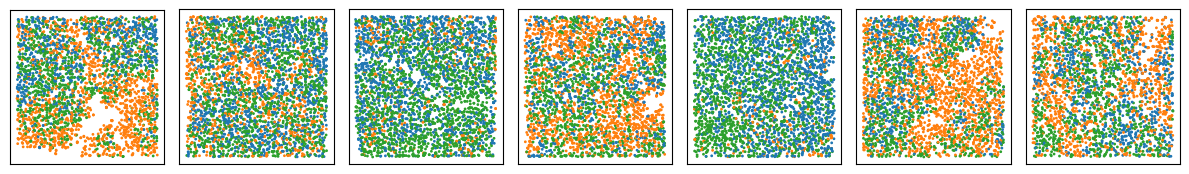

In [32]:
fig, axs = plt.subplots(1, n_mice, figsize=(12, 3))

for ax, grid, label in zip(axs, grids, grid_labels):
    ax.scatter(grid[:, 0], grid[:, 1], c=np.array(colors)[label], s=1,)# cmap='tab10')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## behavior

In [140]:
torch.quantile?

Docstring:
quantile(input, q, dim=None, keepdim=False, *, interpolation='linear', out=None) -> Tensor

Computes the q-th quantiles of each row of the :attr:`input` tensor along the dimension :attr:`dim`.

To compute the quantile, we map q in [0, 1] to the range of indices [0, n] to find the location
of the quantile in the sorted input. If the quantile lies between two data points ``a < b`` with
indices ``i`` and ``j`` in the sorted order, result is computed according to the given
:attr:`interpolation` method as follows:

- ``linear``: ``a + (b - a) * fraction``, where ``fraction`` is the fractional part of the computed quantile index.
- ``lower``: ``a``.
- ``higher``: ``b``.
- ``nearest``: ``a`` or ``b``, whichever's index is closer to the computed quantile index (follows :func:`torch.round`).
- ``midpoint``: ``(a + b) / 2``.

If :attr:`q` is a 1D tensor, the first dimension of the output represents the quantiles and has size
equal to the size of :attr:`q`, the remaining dimensions are

In [143]:
behavs = {}
bounds = {}
for k, loader in dataloaders['train'].items():
    animal_behavs = []
    for batch in loader:
        img = batch[0].cpu()
        behav = img[:, 1:, 0, 0]
        animal_behavs.append(behav)
    animal_behavs = torch.cat(animal_behavs)
    lo = animal_behavs.quantile(0.01, dim=0)
    hi = animal_behavs.quantile(0.99, dim=0)
    behavs[k] = animal_behavs
    bounds[k] = (lo, hi)

In [144]:
bounds

{'23343-5-17': (tensor([ 1.1200, -2.5618, -6.0852]),
  tensor([5.2409, 2.6564, 0.3908])),
 '23964-4-22': (tensor([ 1.0489, -2.6612, -1.5665]),
  tensor([5.3690, 2.7866, 2.0783])),
 '23656-14-22': (tensor([ 2.2050, -2.4688, -3.6543]),
  tensor([6.1815, 2.4402, 0.3285])),
 '21067-10-18': (tensor([ 0.7646, -2.8842, -0.3468]),
  tensor([4.1528, 2.8677, 1.2498])),
 '26872-17-20': (tensor([0., 0., 0.]), tensor([0., 0., 0.])),
 '22846-10-16': (tensor([ 0.7352, -2.6514, -6.0550]),
  tensor([4.4573, 2.6658, 0.0576])),
 '27204-5-13': (tensor([ 0.8319, -2.9370, -2.8180]),
  tensor([4.4961, 2.3876, 1.6804]))}

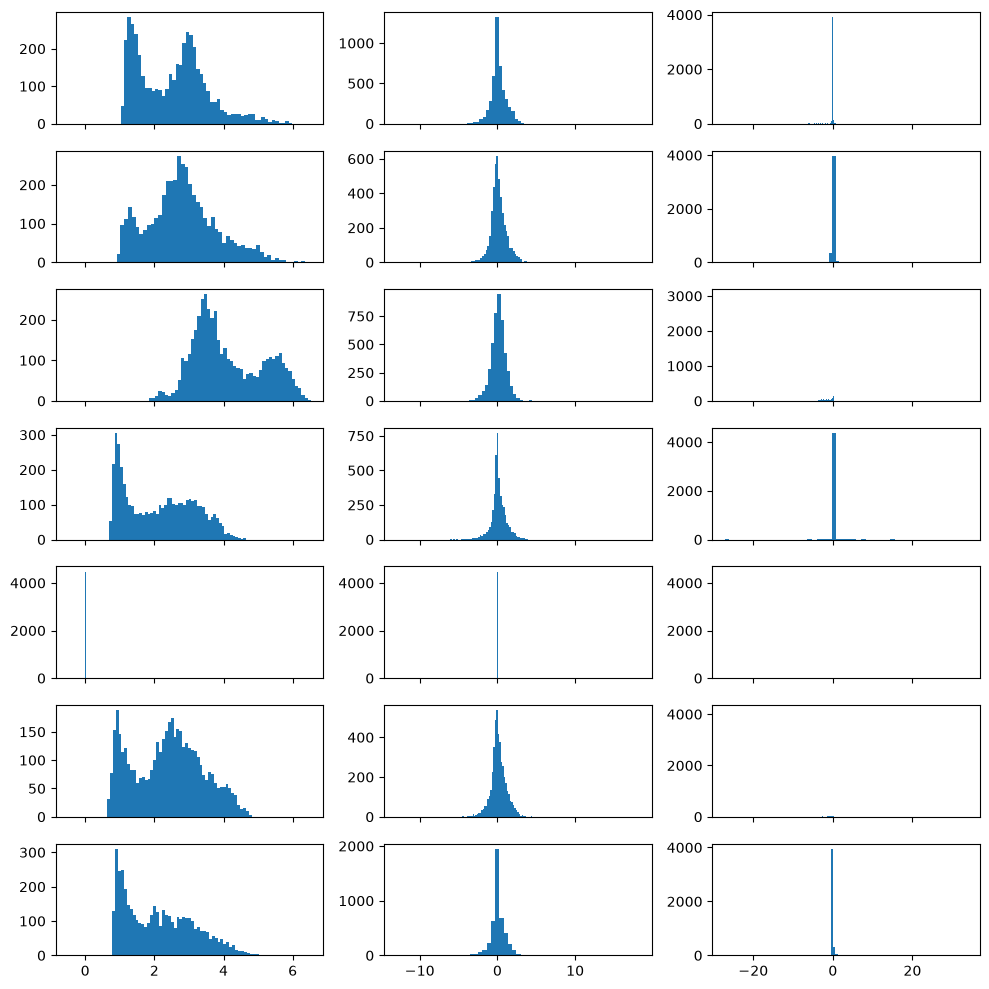

In [137]:
fig, axs = plt.subplots(7, 3, figsize=(10, 10), sharex='col')

for i, key in enumerate(behavs):
    behav = behavs[key]
    
    ax = axs[i, 0]
    ax.hist(behav[:, 0], bins=50)
    
    ax = axs[i, 1]
    ax.hist(behav[:, 1], bins=50)
    
    ax = axs[i, 2]
    ax.hist(behav[:, 2], bins=50)

plt.tight_layout()
plt.show()

In [225]:
key = data_keys[0]
behav_nr = 0
los, his = bounds[key]
lo, hi = los[behav_nr], his[behav_nr]
steps = 50
behav = torch.linspace(lo, hi, steps=steps)

img = torch.zeros(steps, 4, 36, 64, device=device)
img[:, 1 + behav_nr, :, :] = behav[:, None, None]

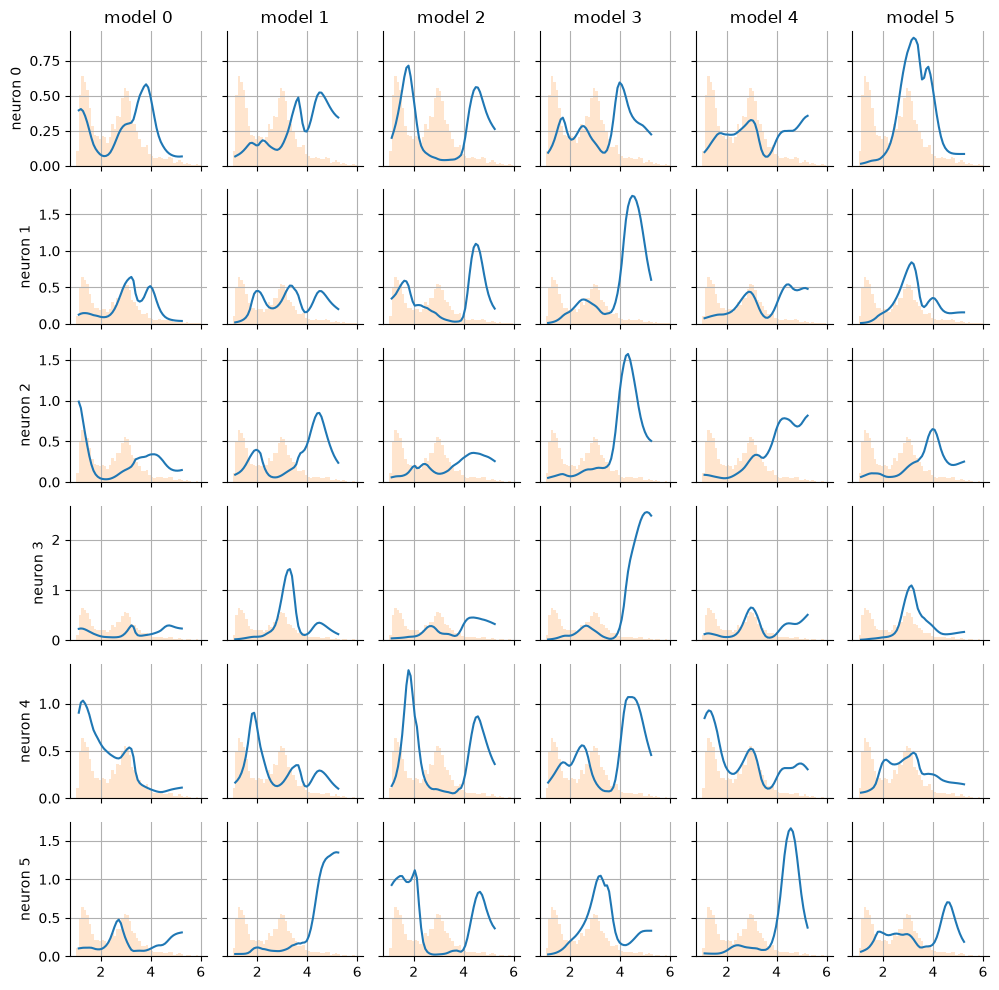

In [230]:
fig, axs = plt.subplots(6, 6, sharey='row', sharex=True, figsize=(10, 10))
for i in range(6):
    model = models[i]
    pred = model(img, data_key=key).cpu().detach()
    axs[0, i].set_title(f'model {i}')
    for j in range(6):
        ax = axs[j, i]
        ax.plot(behav, pred[:, j])
        ax.hist(behavs[key][:, behav_nr], density=True, bins=50, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid()
        if i == 0:
            ax.set_ylabel(f'neuron {j}')

plt.tight_layout()
plt.show()

In [231]:
key = data_keys[0]
imgs = []
for behav_nr in [0, 1, 2]:
    los, his = bounds[key]
    lo, hi = los[behav_nr], his[behav_nr]
    steps = 50
    behav = torch.linspace(lo, hi, steps=steps)

    img = torch.zeros(steps, 4, 36, 64, device=device)
    img[:, 1 + behav_nr, :, :] = behav[:, None, None]
    imgs.append(img)

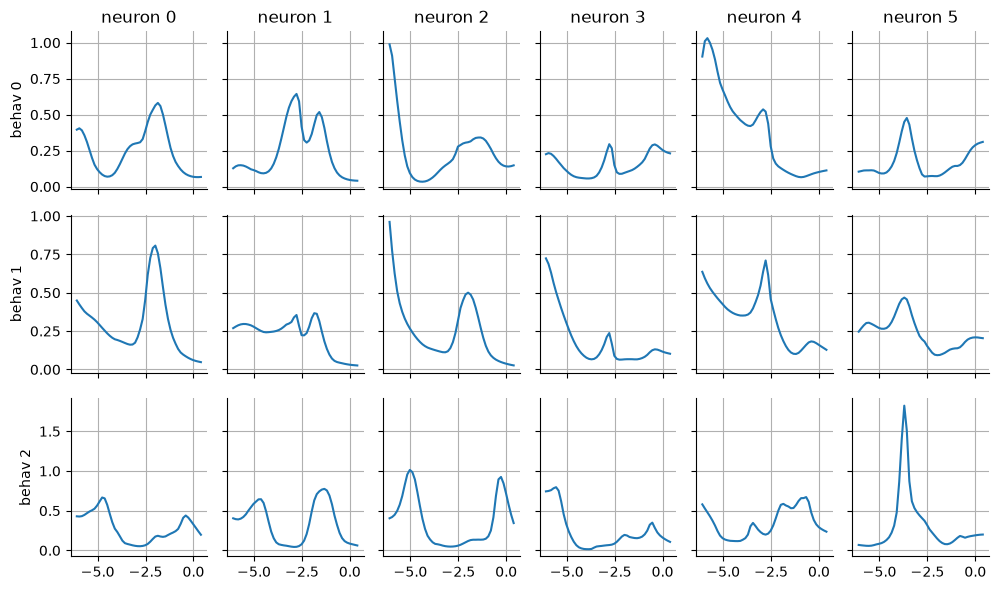

In [240]:
fig, axs = plt.subplots(3, 6, sharey='row', sharex=True, figsize=(10, 6))
for i in range(6):
    for j in range(3):
        model = models[0]
        pred = model(imgs[j], data_key=key).cpu().detach()
        axs[0, i].set_title(f'neuron {i}')
        ax = axs[j, i]
        ax.plot(behav, pred[:, i])
        # ax.hist(behavs[key][:, j], density=True, bins=50, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid()
        if i == 0:
            ax.set_ylabel(f'behav {j}')

plt.tight_layout()
plt.show()